

## Experiment 9: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering


---
## Step 0: Install Required Libraries

In [1]:
!pip install scikit-learn matplotlib seaborn pandas numpy scipy -q

---
## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score, confusion_matrix
)

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment

# Neighbors for DBSCAN epsilon estimation
from sklearn.neighbors import NearestNeighbors

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load Dataset

**Files used from:**  
`C:\Users\janis\ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test`

- `X_test.txt` — 2947 samples × 561 features  
- `y_test.txt` — 2947 activity labels (1 to 6)  
- `subject_test.txt` — subject IDs

In [3]:
# ── PATH — update if your folder is different ─────────────────────────────────
TEST_PATH = r"C:\Users\janis\ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test"

# ── Load Files ────────────────────────────────────────────────────────────────
X = pd.read_csv(TEST_PATH + r"\X_test.txt", header=None, sep=r'\s+')
y_df = pd.read_csv(TEST_PATH + r"\y_test.txt", header=None, names=['activity'])
subject_df = pd.read_csv(TEST_PATH + r"\subject_test.txt", header=None, names=['subject'])

y = y_df['activity'].values

print(f"X shape   : {X.shape}   (samples x features)")
print(f"y shape   : {y.shape}")
print(f"Subjects  : {subject_df['subject'].nunique()} unique volunteers")
print(f"\nRaw activity label counts:")
print(y_df['activity'].value_counts().sort_index())

X shape   : (2947, 561)   (samples x features)
y shape   : (2947,)
Subjects  : 9 unique volunteers

Raw activity label counts:
activity
1    496
2    471
3    420
4    491
5    532
6    537
Name: count, dtype: int64


In [4]:
# ── Activity label mapping ─────────────────────────────────────────────────────
activity_labels = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

y_int = y.astype(int)
y_labels = np.array([activity_labels[i] for i in y_int])

print("Activity Distribution:")
for act_id, act_name in activity_labels.items():
    count = np.sum(y_int == act_id)
    print(f"  {act_id}  {act_name:<25}: {count} samples")

Activity Distribution:
  1  WALKING                  : 496 samples
  2  WALKING_UPSTAIRS         : 471 samples
  3  WALKING_DOWNSTAIRS       : 420 samples
  4  SITTING                  : 491 samples
  5  STANDING                 : 532 samples
  6  LAYING                   : 537 samples


---
## Step 3: Preprocessing

In [5]:
print("=== Preprocessing ===")
print(f"Shape         : {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Data types    : {X.dtypes.unique()}")

# Handle missing values
X = X.fillna(X.mean())
print(f"Missing after : {X.isnull().sum().sum()}")

# Standardize
# Note: HAR features are already normalized [-1,1] by dataset authors.
# StandardScaler is applied additionally for clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nAfter StandardScaler:")
print(f"  Mean : {X_scaled.mean():.6f}  (expected ~0)")
print(f"  Std  : {X_scaled.std():.6f}  (expected ~1)")

=== Preprocessing ===
Shape         : (2947, 561)
Missing values: 0
Data types    : [dtype('float64')]
Missing after : 0

After StandardScaler:
  Mean : 0.000000  (expected ~0)
  Std  : 1.000000  (expected ~1)


---
## Step 4: Exploratory Data Analysis (EDA)

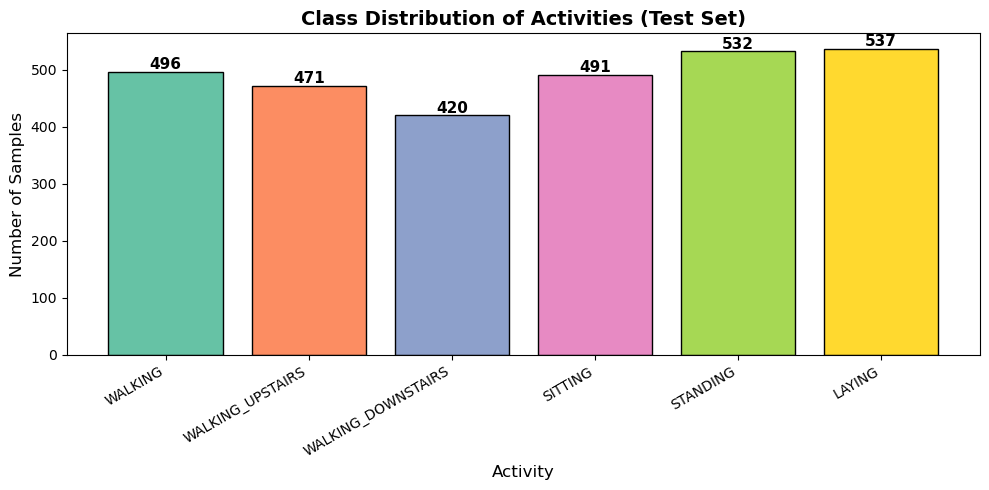

Saved: eda_class_distribution.png


In [6]:
# ── 4.1 Class Distribution ────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
act_names  = [activity_labels[i] for i in sorted(activity_labels)]
act_counts = [np.sum(y_int == i) for i in sorted(activity_labels)]
colors = sns.color_palette("Set2", 6)

bars = plt.bar(act_names, act_counts, color=colors, edgecolor='black')
for bar, val in zip(bars, act_counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, str(val),
             ha='center', fontsize=11, fontweight='bold')

plt.title('Class Distribution of Activities (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Activity', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()
print("Saved: eda_class_distribution.png")

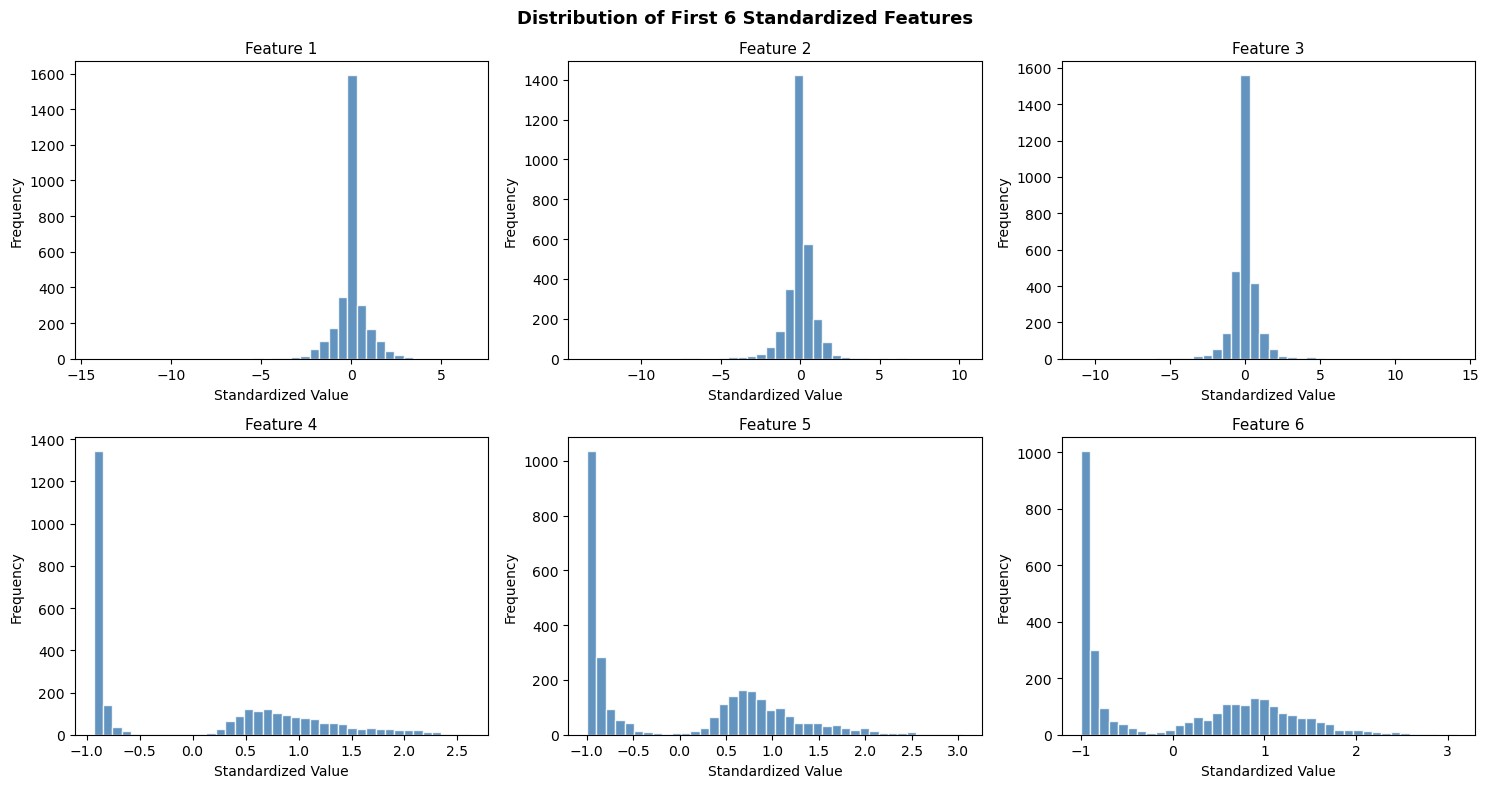

Saved: eda_feature_distributions.png


In [7]:
# ── 4.2 Feature Distributions (first 6 features) ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    ax.hist(X_scaled[:, i], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature {i+1}', fontsize=11)
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frequency')
plt.suptitle('Distribution of First 6 Standardized Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150)
plt.show()
print("Saved: eda_feature_distributions.png")

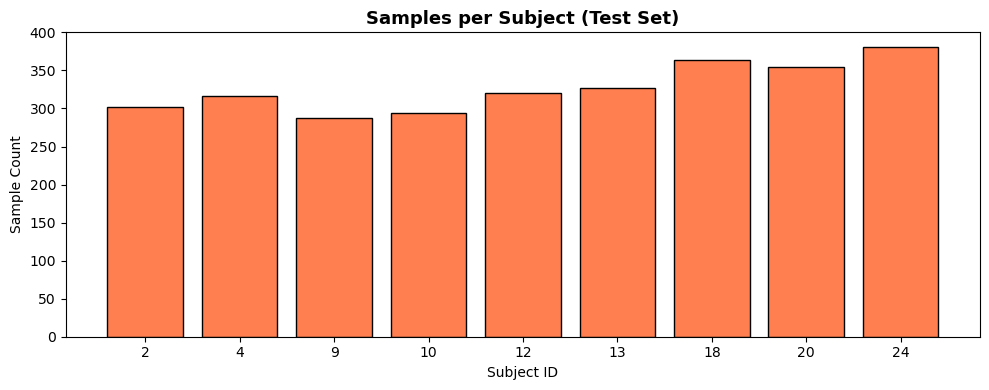

Saved: eda_subject_distribution.png


In [8]:
# ── 4.3 Subject-wise Sample Count ────────────────────────────────────────────
plt.figure(figsize=(10, 4))
subj_counts = subject_df['subject'].value_counts().sort_index()
plt.bar(subj_counts.index.astype(str), subj_counts.values,
        color='coral', edgecolor='black')
plt.title('Samples per Subject (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Subject ID')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.savefig('eda_subject_distribution.png', dpi=150)
plt.show()
print("Saved: eda_subject_distribution.png")

---
## Step 5: Dimensionality Reduction — PCA & t-SNE

PCA 2D  Explained Variance : 56.80%
PCA 50D Explained Variance : 87.78%


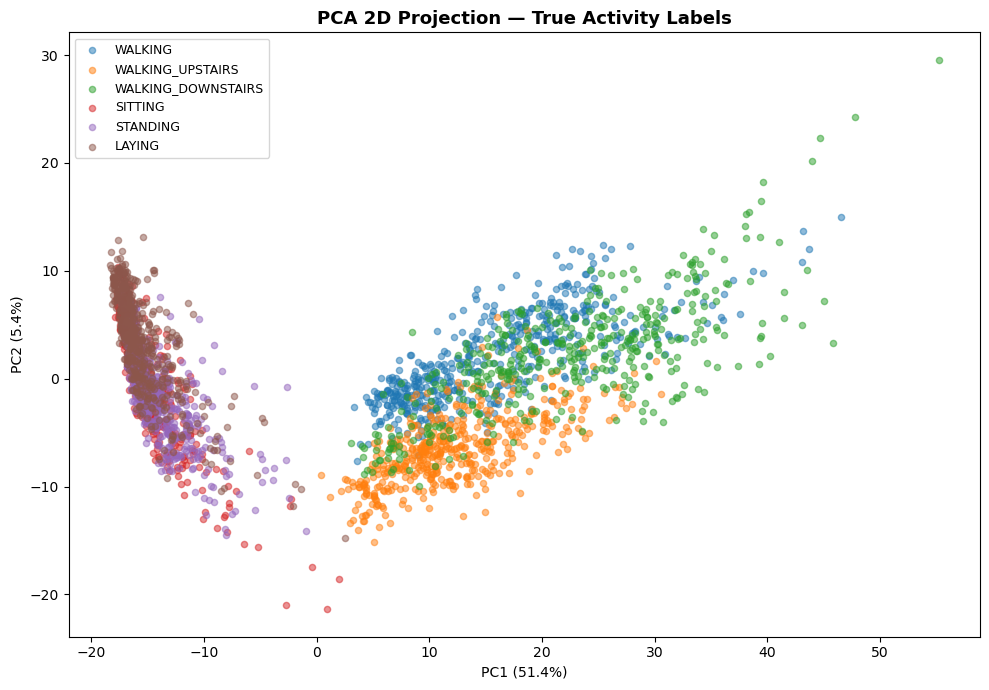

Saved: pca_true_labels.png


In [9]:
# ── 5.1 PCA ───────────────────────────────────────────────────────────────────
pca2  = PCA(n_components=2,  random_state=42)
pca50 = PCA(n_components=50, random_state=42)

X_pca2  = pca2.fit_transform(X_scaled)
X_pca50 = pca50.fit_transform(X_scaled)

print(f"PCA 2D  Explained Variance : {pca2.explained_variance_ratio_.sum()*100:.2f}%")
print(f"PCA 50D Explained Variance : {pca50.explained_variance_ratio_.sum()*100:.2f}%")

# PCA scatter with true labels
palette = sns.color_palette("tab10", 6)
plt.figure(figsize=(10, 7))
for i, (act_id, act_name) in enumerate(activity_labels.items()):
    mask = y_int == act_id
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=[palette[i]], label=act_name, alpha=0.5, s=20)
plt.title('PCA 2D Projection — True Activity Labels', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pca_true_labels.png', dpi=150)
plt.show()
print("Saved: pca_true_labels.png")

Running t-SNE on PCA-50D data... (~1-2 min)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2947 samples in 0.003s...
[t-SNE] Computed neighbors for 2947 samples in 0.916s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2947
[t-SNE] Computed conditional probabilities for sample 2000 / 2947
[t-SNE] Computed conditional probabilities for sample 2947 / 2947
[t-SNE] Mean sigma: 4.367973
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.875809
[t-SNE] KL divergence after 1000 iterations: 1.022102


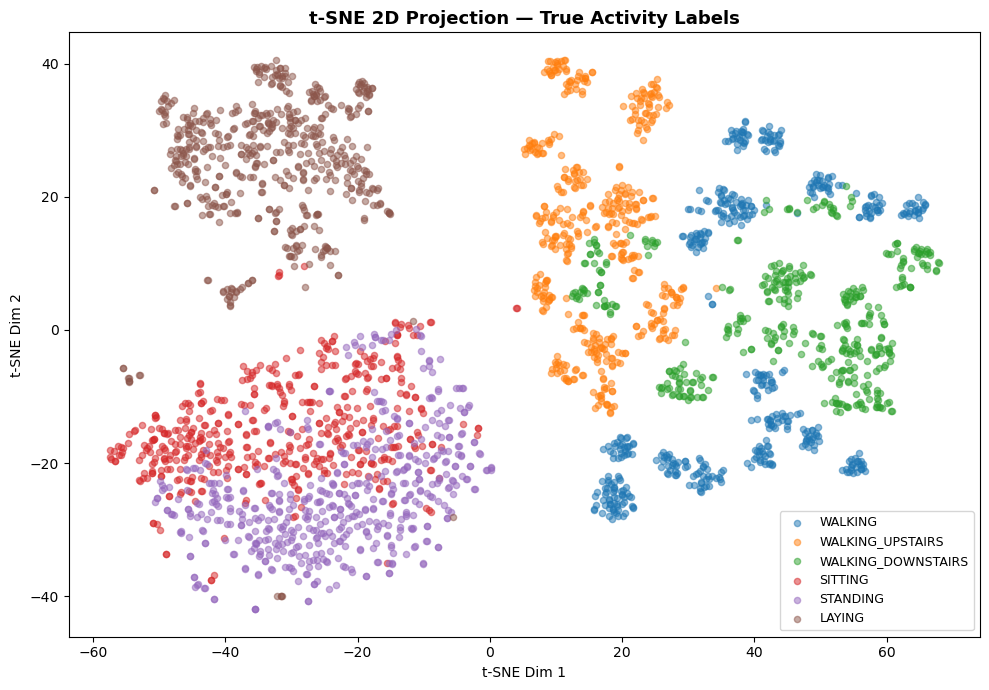

Saved: tsne_true_labels.png


In [10]:
# ── 5.2 t-SNE ─────────────────────────────────────────────────────────────────
print("Running t-SNE on PCA-50D data... (~1-2 min)")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_pca50)

plt.figure(figsize=(10, 7))
for i, (act_id, act_name) in enumerate(activity_labels.items()):
    mask = y_int == act_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=[palette[i]], label=act_name, alpha=0.5, s=20)
plt.title('t-SNE 2D Projection — True Activity Labels', fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('tsne_true_labels.png', dpi=150)
plt.show()
print("Saved: tsne_true_labels.png")

---
## Step 6: Model A — K-Means Clustering

### Theory
- **Objective:** Minimize Within-Cluster Sum of Squares (WCSS)
- **Distance:** Euclidean
- **Algorithm:** Initialize k centroids → Assign each point to nearest centroid → Update centroids as mean → Repeat until convergence

### Elbow Method
Compute WCSS for k = 2 to 8. The 'elbow point' where WCSS reduction slows down gives the optimal k.

In [11]:
# ── 6.1 Elbow Method — k = 2 to 8 ────────────────────────────────────────────
k_values       = list(range(2, 9))
wcss_list      = []
silhouette_list = []

print(f"{'k':>4} | {'WCSS (Inertia)':>18} | {'Silhouette Score':>18}")
print("-" * 46)

for k in k_values:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10,
                 max_iter=300, random_state=42)
    km.fit(X_scaled)
    wcss = km.inertia_
    sil  = silhouette_score(X_scaled, km.labels_,
                            sample_size=1500, random_state=42)
    wcss_list.append(wcss)
    silhouette_list.append(sil)
    print(f"{k:>4} | {wcss:>18.2f} | {sil:>18.4f}")

   k |     WCSS (Inertia) |   Silhouette Score
----------------------------------------------
   2 |          918351.30 |             0.3963
   3 |          814303.31 |             0.3076
   4 |          777281.30 |             0.1368
   5 |          750010.25 |             0.1072
   6 |          729516.26 |             0.1038
   7 |          711693.28 |             0.1078
   8 |          697957.15 |             0.1031


In [12]:
# ── 6.2 TABLE 1: K-Means Elbow Method Results ─────────────────────────────────
elbow_df = pd.DataFrame({
    'Number of Clusters (k)': k_values,
    'WCSS (Inertia)'        : [round(w, 2) for w in wcss_list],
    'Silhouette Score'      : [round(s, 4) for s in silhouette_list]
})

print("\n" + "="*55)
print("  TABLE 1: K-Means Elbow Method Results")
print("="*55)
print(elbow_df.to_string(index=False))
print("="*55)


  TABLE 1: K-Means Elbow Method Results
 Number of Clusters (k)  WCSS (Inertia)  Silhouette Score
                      2       918351.30            0.3963
                      3       814303.31            0.3076
                      4       777281.30            0.1368
                      5       750010.25            0.1072
                      6       729516.26            0.1038
                      7       711693.28            0.1078
                      8       697957.15            0.1031


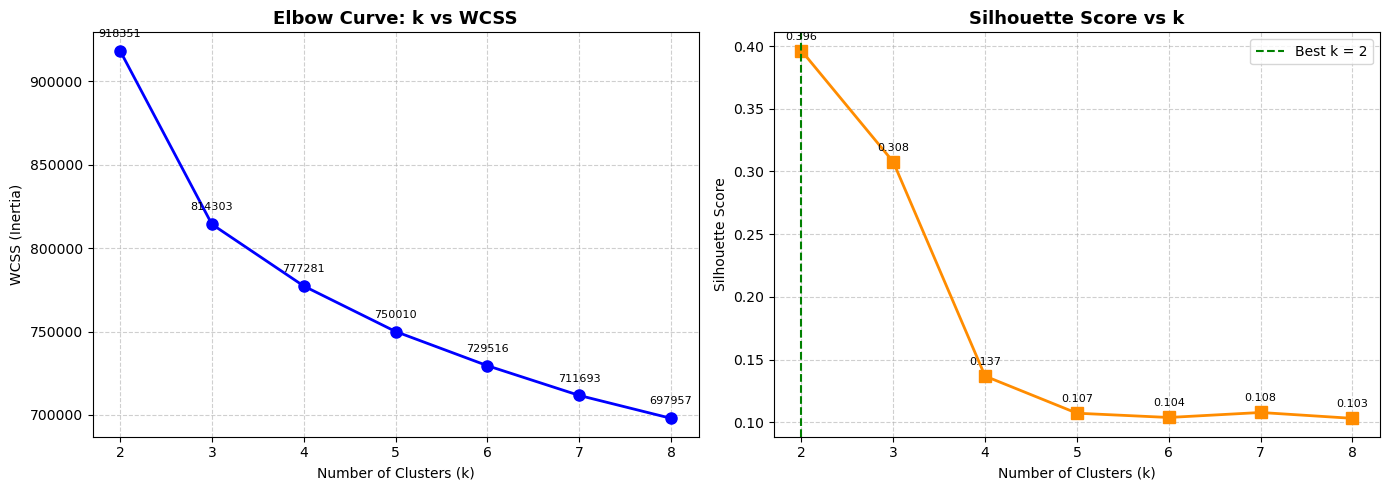

Saved: kmeans_elbow_silhouette.png


In [13]:
# ── 6.3 Elbow Curve + Silhouette Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_values, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Curve: k vs WCSS', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_xticks(k_values)
axes[0].grid(True, linestyle='--', alpha=0.6)
for k, w in zip(k_values, wcss_list):
    axes[0].annotate(f'{w:.0f}', (k, w),
                     textcoords='offset points', xytext=(0,10),
                     ha='center', fontsize=8)

# Silhouette curve
best_k_idx = silhouette_list.index(max(silhouette_list))
axes[1].plot(k_values, silhouette_list, 's-', linewidth=2,
             markersize=8, color='darkorange')
axes[1].axvline(x=k_values[best_k_idx], color='green', linestyle='--',
                label=f'Best k = {k_values[best_k_idx]}')
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_values)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()
for k, s in zip(k_values, silhouette_list):
    axes[1].annotate(f'{s:.3f}', (k, s),
                     textcoords='offset points', xytext=(0,8),
                     ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
plt.show()
print("Saved: kmeans_elbow_silhouette.png")

In [14]:
# ── 6.4 Final K-Means with k=6 ────────────────────────────────────────────────
BEST_K = 6   # HAR has exactly 6 activity classes

kmeans    = KMeans(n_clusters=BEST_K, init='k-means++', n_init=20,
                   max_iter=500, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

print(f"K-Means Final Model (k={BEST_K})")
print(f"Inertia (WCSS) : {kmeans.inertia_:.2f}")
print("\nCluster sizes:")
for u, c in zip(*np.unique(km_labels, return_counts=True)):
    print(f"  Cluster {u} : {c} samples")

K-Means Final Model (k=6)
Inertia (WCSS) : 729514.04

Cluster sizes:
  Cluster 0 : 722 samples
  Cluster 1 : 665 samples
  Cluster 2 : 499 samples
  Cluster 3 : 456 samples
  Cluster 4 : 225 samples
  Cluster 5 : 380 samples


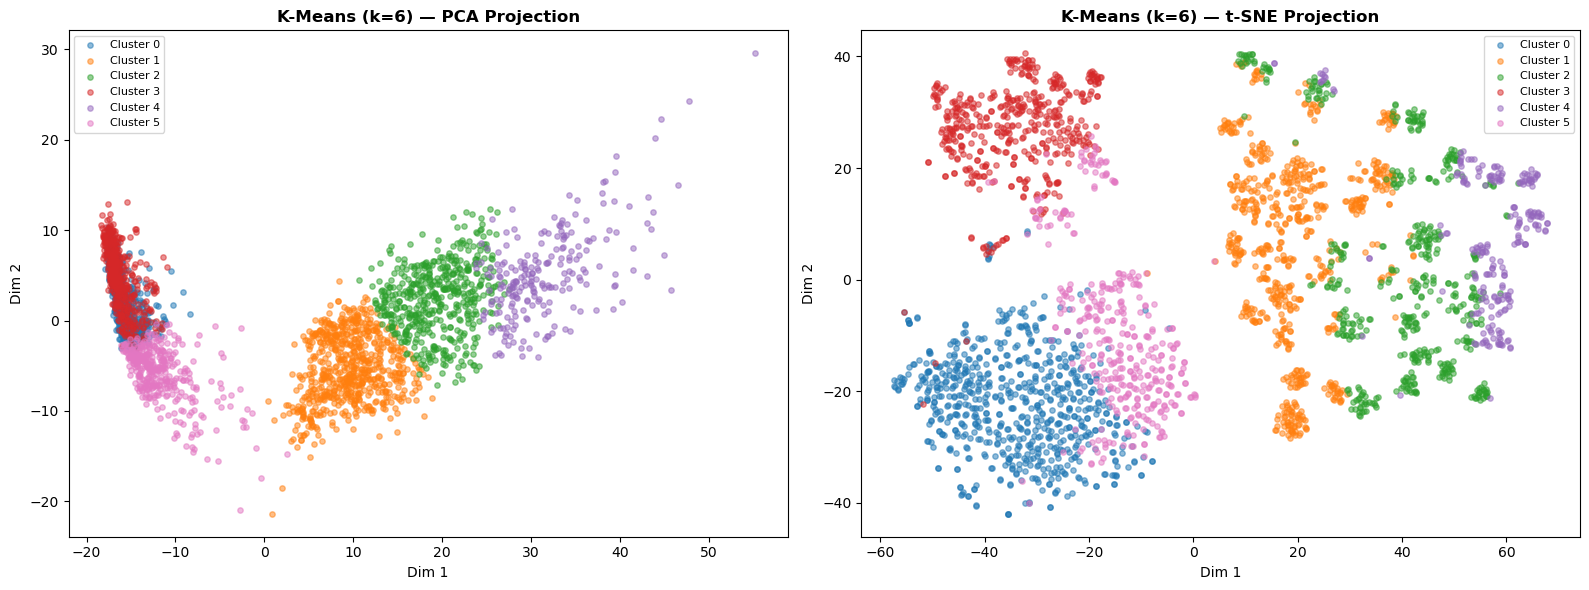

Saved: kmeans_clusters.png


In [15]:
# ── 6.5 K-Means Cluster Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap = cm.tab10(np.linspace(0, 0.6, BEST_K))

for ax, X_2d, title in zip(
        axes, [X_pca2, X_tsne], ['PCA Projection', 't-SNE Projection']):
    for c in range(BEST_K):
        mask = km_labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[cmap[c]], label=f'Cluster {c}', alpha=0.5, s=15)
    ax.set_title(f'K-Means (k={BEST_K}) — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()
print("Saved: kmeans_clusters.png")

---
## Step 7: Model B — DBSCAN Clustering

### Theory
- **Parameters:** ε (neighborhood radius), minPts (minimum points to form a dense region)
- **Core point:** Has at least minPts neighbours within ε
- **Border point:** Within ε of a core point but fewer than minPts neighbours
- **Noise:** Neither core nor border
- **Advantage:** Finds clusters of arbitrary shape, handles outliers

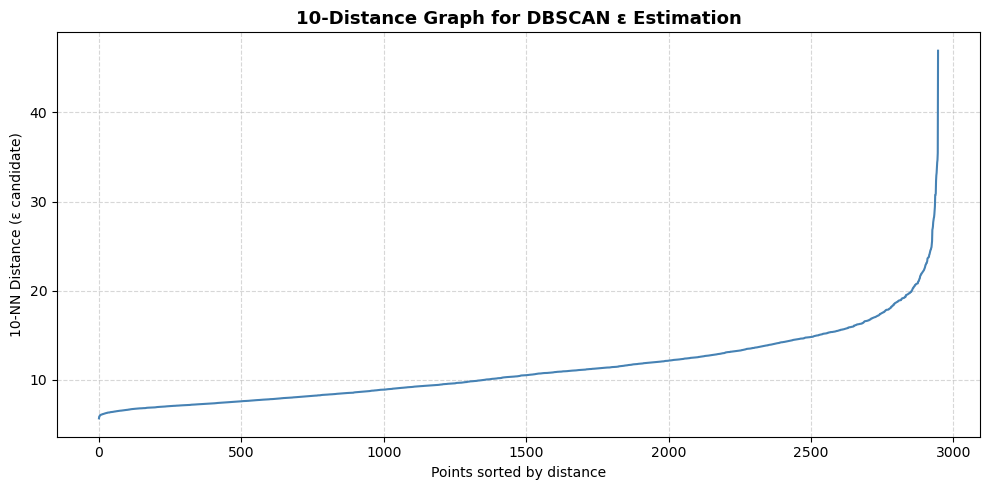

Saved: dbscan_epsilon_estimation.png
→ The 'knee' of this curve is the best ε value


In [16]:
# ── 7.1 k-Distance Graph to Choose ε ──────────────────────────────────────────
MIN_PTS = 10
nbrs = NearestNeighbors(n_neighbors=MIN_PTS).fit(X_pca50)
distances, _ = nbrs.kneighbors(X_pca50)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
plt.title(f'{MIN_PTS}-Distance Graph for DBSCAN ε Estimation',
          fontsize=13, fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_PTS}-NN Distance (ε candidate)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('dbscan_epsilon_estimation.png', dpi=150)
plt.show()
print("Saved: dbscan_epsilon_estimation.png")
print("→ The 'knee' of this curve is the best ε value")

In [17]:
# ── 7.2 DBSCAN Hyperparameter Search ──────────────────────────────────────────
eps_candidates   = [1.5, 2.0, 2.5, 3.0, 4.0]
minpts_candidates = [5, 10, 15]

print(f"{'eps':>6} | {'min_samples':>12} | {'Clusters':>10} | {'Noise%':>8} | {'Silhouette':>12}")
print("-" * 58)

best_eps, best_mp, best_sil = 2.5, 10, -1

for eps in eps_candidates:
    for mp in minpts_candidates:
        db  = DBSCAN(eps=eps, min_samples=mp)
        lbl = db.fit_predict(X_pca50)
        n_cl    = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = list(lbl).count(-1)
        noise_p = 100 * n_noise / len(lbl)
        if n_cl >= 2 and (lbl != -1).sum() > 100:
            sil = silhouette_score(X_pca50[lbl != -1], lbl[lbl != -1],
                                   sample_size=1500, random_state=42)
            if sil > best_sil:
                best_sil, best_eps, best_mp = sil, eps, mp
            print(f"{eps:>6.1f} | {mp:>12} | {n_cl:>10} | {noise_p:>7.1f}% | {sil:>12.4f}")
        else:
            print(f"{eps:>6.1f} | {mp:>12} | {n_cl:>10} | {noise_p:>7.1f}% | {'N/A':>12}")

print(f"\nBest params → eps={best_eps}, min_samples={best_mp}, silhouette={best_sil:.4f}")

   eps |  min_samples |   Clusters |   Noise% |   Silhouette
----------------------------------------------------------
   1.5 |            5 |          0 |   100.0% |          N/A
   1.5 |           10 |          0 |   100.0% |          N/A
   1.5 |           15 |          0 |   100.0% |          N/A
   2.0 |            5 |          0 |   100.0% |          N/A
   2.0 |           10 |          0 |   100.0% |          N/A
   2.0 |           15 |          0 |   100.0% |          N/A
   2.5 |            5 |          0 |   100.0% |          N/A
   2.5 |           10 |          0 |   100.0% |          N/A
   2.5 |           15 |          0 |   100.0% |          N/A
   3.0 |            5 |          0 |   100.0% |          N/A
   3.0 |           10 |          0 |   100.0% |          N/A
   3.0 |           15 |          0 |   100.0% |          N/A
   4.0 |            5 |          0 |   100.0% |          N/A
   4.0 |           10 |          0 |   100.0% |          N/A
   4.0 |           15 |   

In [18]:
# ── 7.3 Final DBSCAN ──────────────────────────────────────────────────────────
dbscan    = DBSCAN(eps=best_eps, min_samples=best_mp)
db_labels = dbscan.fit_predict(X_pca50)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = list(db_labels).count(-1)

print(f"DBSCAN (eps={best_eps}, min_samples={best_mp})")
print(f"  Clusters : {n_clusters_db}")
print(f"  Noise    : {n_noise_db}  ({100*n_noise_db/len(db_labels):.1f}%)")
print("\nCluster sizes:")
for u, c in zip(*np.unique(db_labels, return_counts=True)):
    print(f"  {'Noise' if u==-1 else f'Cluster {u}'}: {c}")

DBSCAN (eps=2.5, min_samples=10)
  Clusters : 0
  Noise    : 2947  (100.0%)

Cluster sizes:
  Noise: 2947


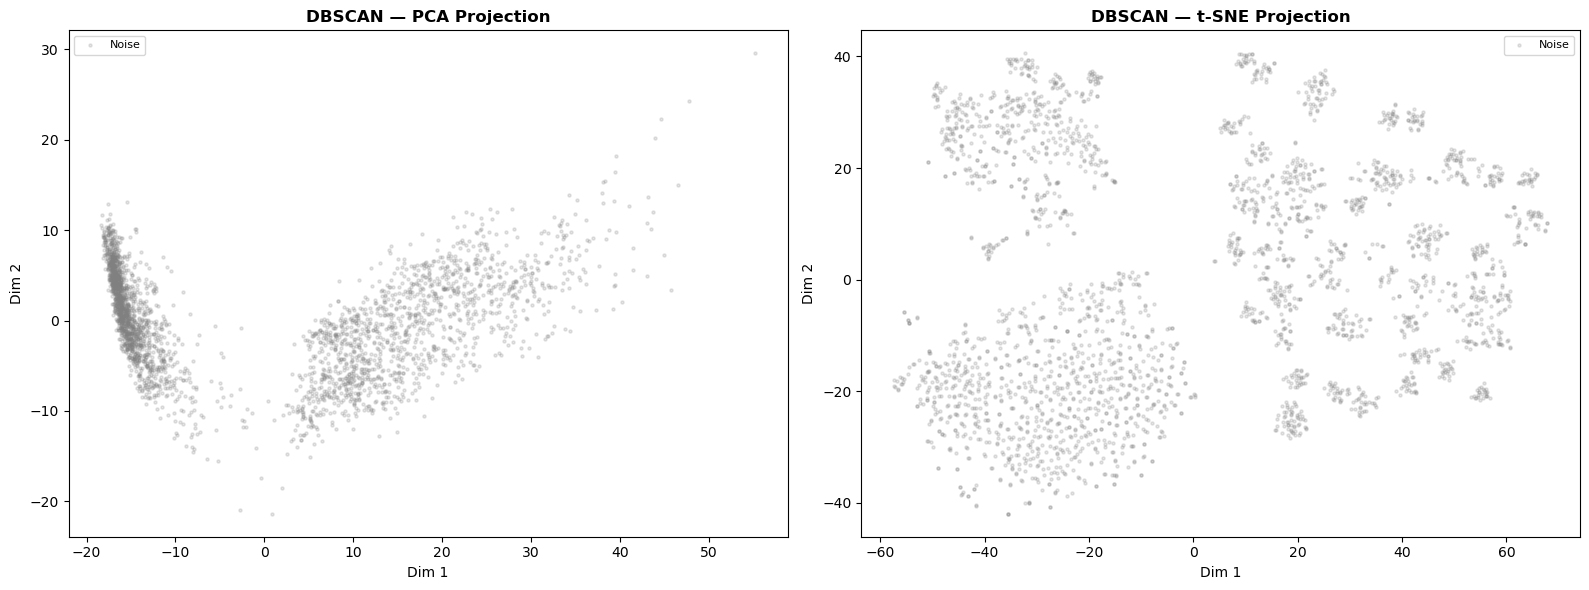

Saved: dbscan_clusters.png


In [19]:
# ── 7.4 DBSCAN Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
unique_db  = sorted(set(db_labels))
db_palette = cm.tab10(np.linspace(0, 1, max(n_clusters_db, 2)))

for ax, X_2d, title in zip(
        axes, [X_pca2, X_tsne], ['PCA Projection', 't-SNE Projection']):
    for lv in unique_db:
        mask = db_labels == lv
        if lv == -1:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c='grey', s=5, alpha=0.2, label='Noise')
        else:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[db_palette[lv % len(db_palette)]],
                       s=15, alpha=0.5, label=f'Cluster {lv}')
    ax.set_title(f'DBSCAN — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()
print("Saved: dbscan_clusters.png")

---
## Step 8: Model C — Hierarchical Agglomerative Clustering (HAC)

### Theory
- **Agglomerative (bottom-up):** Each point starts as its own cluster; merge closest pairs iteratively
- **Linkage criteria:**
  - **Ward:** Minimises total within-cluster variance ← best for HAR
  - **Complete:** Uses maximum distance between clusters
  - **Average:** Uses average distance between all pairs
  - **Single:** Uses minimum distance (prone to chaining)
- Visualised as a **Dendrogram**

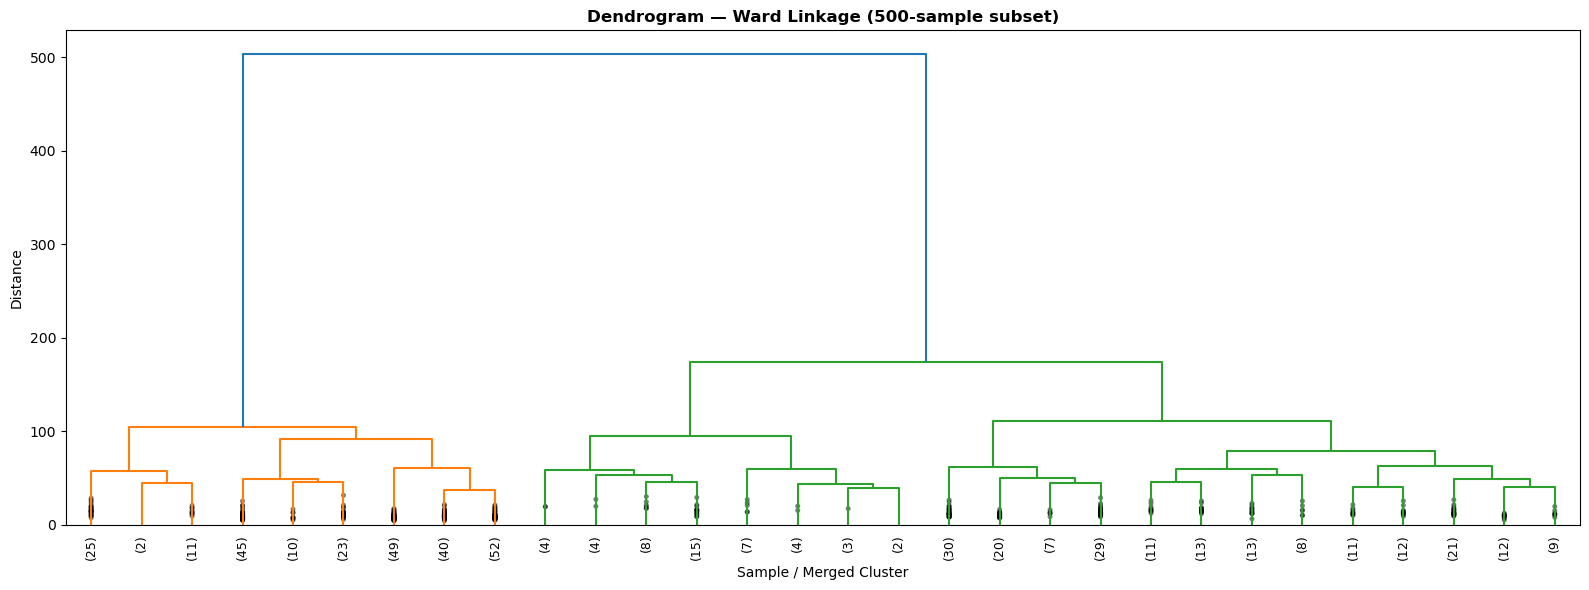

Saved: hac_dendrogram.png


In [20]:
# ── 8.1 Dendrogram (500-sample subset for speed) ──────────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca50), size=500, replace=False)
X_sample   = X_pca50[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(Z,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=9,
           show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title('Dendrogram — Ward Linkage (500-sample subset)',
          fontsize=12, fontweight='bold')
plt.xlabel('Sample / Merged Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('hac_dendrogram.png', dpi=150)
plt.show()
print("Saved: hac_dendrogram.png")

In [21]:
# ── 8.2 Compare Linkage Methods ───────────────────────────────────────────────
linkage_methods = ['ward', 'complete', 'average', 'single']
hac_results = {}

print(f"{'Linkage':>10} | {'Silhouette':>12} | {'Davies-Bouldin':>16} | {'Calinski-Harabasz':>20}")
print("-" * 65)

for method in linkage_methods:
    hac = AgglomerativeClustering(n_clusters=BEST_K, linkage=method)
    lbl = hac.fit_predict(X_pca50)
    sil = silhouette_score(X_pca50, lbl, sample_size=1500, random_state=42)
    dbi = davies_bouldin_score(X_pca50, lbl)
    chi = calinski_harabasz_score(X_pca50, lbl)
    hac_results[method] = {'labels': lbl, 'sil': sil, 'dbi': dbi, 'chi': chi}
    print(f"{method:>10} | {sil:>12.4f} | {dbi:>16.4f} | {chi:>20.2f}")

hac_labels = hac_results['ward']['labels']
print("\n→ Ward selected as final HAC model")

   Linkage |   Silhouette |   Davies-Bouldin |    Calinski-Harabasz
-----------------------------------------------------------------
      ward |       0.1386 |           2.5000 |               959.24
  complete |       0.3885 |           1.4503 |               776.63
   average |       0.3614 |           0.8951 |                17.50
    single |       0.3741 |           0.4559 |                 7.96

→ Ward selected as final HAC model


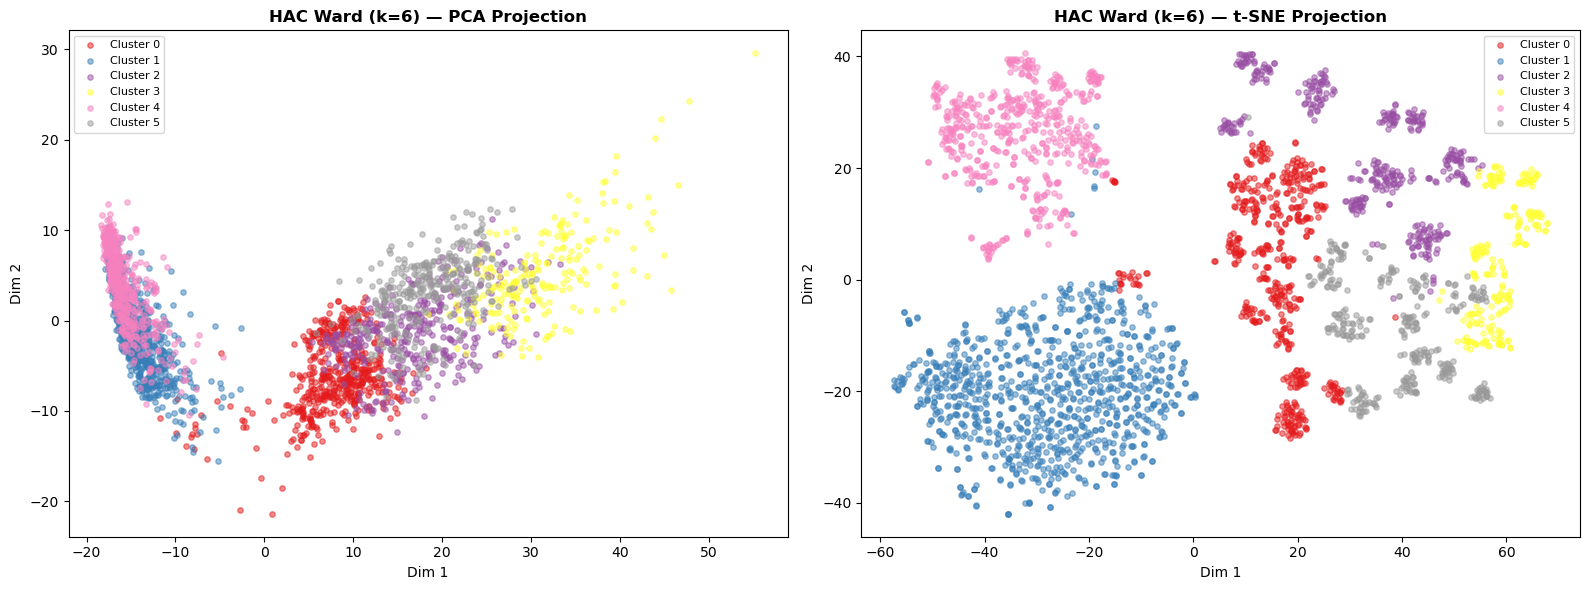

Saved: hac_clusters.png


In [22]:
# ── 8.3 HAC Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hac_colors = cm.Set1(np.linspace(0, 1, BEST_K))

for ax, X_2d, title in zip(
        axes, [X_pca2, X_tsne], ['PCA Projection', 't-SNE Projection']):
    for c in range(BEST_K):
        mask = hac_labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[hac_colors[c]], label=f'Cluster {c}', alpha=0.5, s=15)
    ax.set_title(f'HAC Ward (k={BEST_K}) — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('hac_clusters.png', dpi=150)
plt.show()
print("Saved: hac_clusters.png")

---
## Step 9: Evaluation Metrics

| Metric | Type | Better When |
|---|---|---|
| Silhouette Score | Internal | Higher (max 1) |
| Davies–Bouldin Index | Internal | Lower |
| Calinski–Harabasz Index | Internal | Higher |
| Adjusted Rand Index (ARI) | External | Higher (max 1) |
| Normalized Mutual Info (NMI) | External | Higher (max 1) |

In [23]:
# ── 9.1 Compute All Metrics ───────────────────────────────────────────────────
def compute_metrics(X_data, labels, y_true, name):
    mask = labels != -1
    n_cl = len(set(labels[mask])) if mask.sum() > 0 else 0
    if n_cl < 2 or mask.sum() < 50:
        return {"Algorithm": name, "Clusters": n_cl,
                "Silhouette": None, "Davies-Bouldin": None,
                "Calinski-Harabasz": None, "ARI": None, "NMI": None}
    sil = silhouette_score(X_data[mask], labels[mask],
                           sample_size=1500, random_state=42)
    dbi = davies_bouldin_score(X_data[mask], labels[mask])
    chi = calinski_harabasz_score(X_data[mask], labels[mask])
    ari = adjusted_rand_score(y_true[mask], labels[mask])
    nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
    return {"Algorithm": name, "Clusters": n_cl,
            "Silhouette": round(sil, 4),
            "Davies-Bouldin": round(dbi, 4),
            "Calinski-Harabasz": round(chi, 2),
            "ARI": round(ari, 4),
            "NMI": round(nmi, 4)}

metrics = [
    compute_metrics(X_pca50, km_labels,  y_int, f"K-Means (k={BEST_K})"),
    compute_metrics(X_pca50, db_labels,  y_int, f"DBSCAN (eps={best_eps},mp={best_mp})"),
    compute_metrics(X_pca50, hac_labels, y_int, f"HAC Ward (k={BEST_K})"),
]
metrics_df = pd.DataFrame(metrics)

print("\n" + "="*95)
print("   TABLE 2: Comprehensive Evaluation Metrics")
print("="*95)
print(metrics_df.to_string(index=False))
print("="*95)
print("\nNote: Silhouette/CHI/ARI/NMI higher = better | Davies-Bouldin lower = better")


   TABLE 2: Comprehensive Evaluation Metrics
             Algorithm  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
         K-Means (k=6)         6      0.1433          2.2332            1027.85 0.4344 0.5736
DBSCAN (eps=2.5,mp=10)         0         NaN             NaN                NaN    NaN    NaN
        HAC Ward (k=6)         6      0.1386          2.5000             959.24 0.5077 0.6040

Note: Silhouette/CHI/ARI/NMI higher = better | Davies-Bouldin lower = better


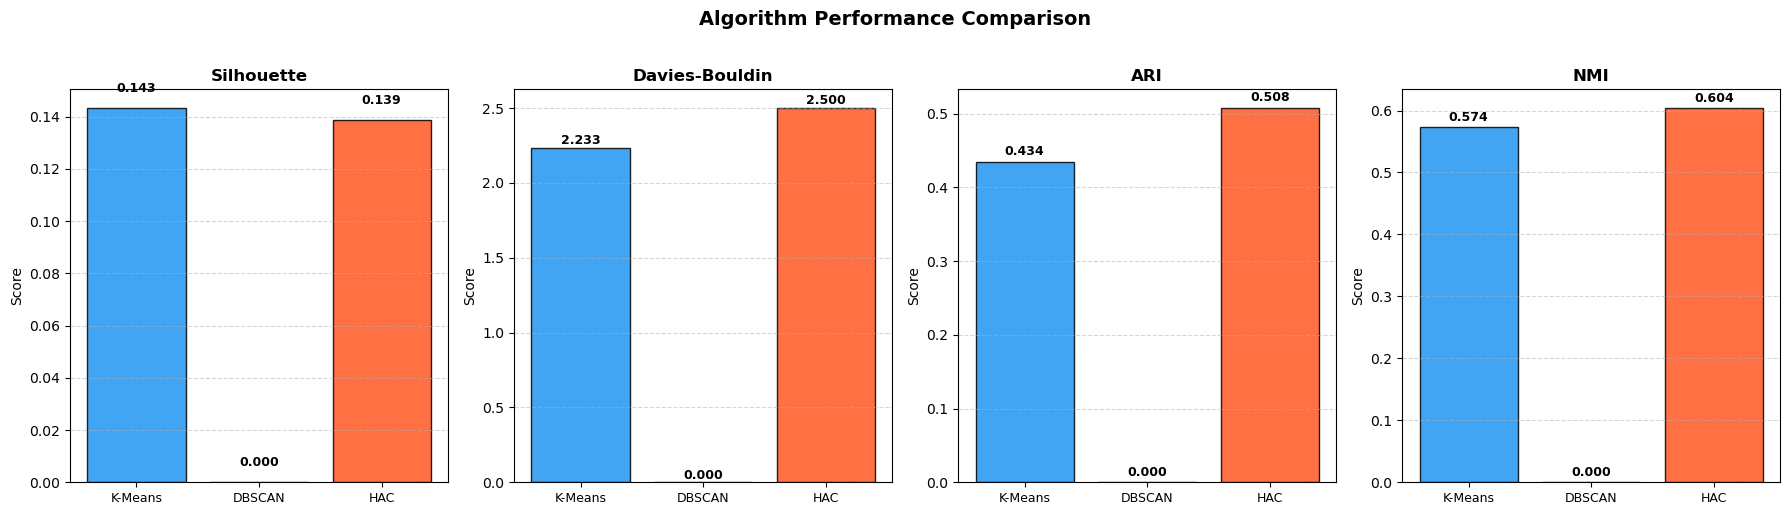

Saved: metrics_comparison.png


In [24]:
# ── 9.2 Bar Plot Comparison ───────────────────────────────────────────────────
metric_cols = ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
algos_short = ['K-Means', 'DBSCAN', 'HAC']

for ax, metric in zip(axes, metric_cols):
    vals = metrics_df[metric].fillna(0).values
    bars = ax.bar(range(3), vals, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(algos_short, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Algorithm Performance Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

---
## Step 10: Confusion Matrix — Cluster to Activity Mapping

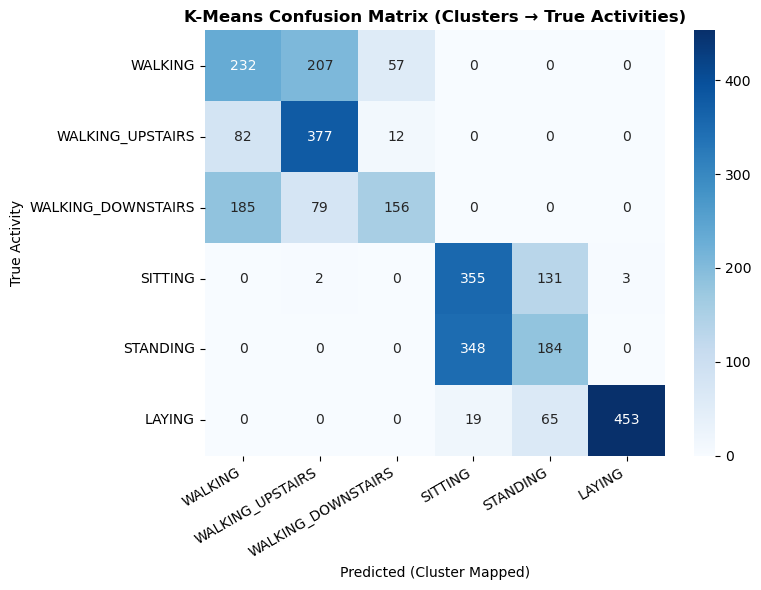

Saved: kmeans_confusion_matrix.png


In [25]:
# ── 10.1 Map clusters → true labels using Hungarian algorithm ─────────────────
def map_clusters(cluster_labels, true_labels, n_clusters):
    act_ids = sorted(activity_labels.keys())
    cost = np.zeros((n_clusters, len(act_ids)))
    for c in range(n_clusters):
        mask = cluster_labels == c
        for j, aid in enumerate(act_ids):
            cost[c, j] = np.sum(true_labels[mask] == aid)
    row, col = linear_sum_assignment(-cost)
    mapping  = {r: act_ids[c] for r, c in zip(row, col)}
    return np.array([mapping.get(l, -1) for l in cluster_labels])

km_mapped     = map_clusters(km_labels, y_int, BEST_K)
act_ids_sorted = sorted(activity_labels.keys())
cm_km          = confusion_matrix(y_int, km_mapped, labels=act_ids_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues',
            xticklabels=[activity_labels[k] for k in act_ids_sorted],
            yticklabels=[activity_labels[k] for k in act_ids_sorted])
plt.title('K-Means Confusion Matrix (Clusters → True Activities)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted (Cluster Mapped)')
plt.ylabel('True Activity')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('kmeans_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: kmeans_confusion_matrix.png")

---
## Step 11: All Results Summary Tables

In [26]:
print("\n" + "="*60)
print("  TABLE 1: K-Means Elbow Method Results")
print("="*60)
print(elbow_df.to_string(index=False))

print("\n\n" + "="*65)
print("  TABLE 2: HAC Linkage Method Comparison")
print("="*65)
hac_table = pd.DataFrame([
    {'Linkage': m,
     'Silhouette': round(v['sil'], 4),
     'Davies-Bouldin': round(v['dbi'], 4),
     'Calinski-Harabasz': round(v['chi'], 2)}
    for m, v in hac_results.items()
])
print(hac_table.to_string(index=False))

print("\n\n" + "="*95)
print("  TABLE 3: Final Algorithm Comparison — All Metrics")
print("="*95)
print(metrics_df.to_string(index=False))
print("="*95)


  TABLE 1: K-Means Elbow Method Results
 Number of Clusters (k)  WCSS (Inertia)  Silhouette Score
                      2       918351.30            0.3963
                      3       814303.31            0.3076
                      4       777281.30            0.1368
                      5       750010.25            0.1072
                      6       729516.26            0.1038
                      7       711693.28            0.1078
                      8       697957.15            0.1031


  TABLE 2: HAC Linkage Method Comparison
 Linkage  Silhouette  Davies-Bouldin  Calinski-Harabasz
    ward      0.1386          2.5000             959.24
complete      0.3885          1.4503             776.63
 average      0.3614          0.8951              17.50
  single      0.3741          0.4559               7.96


  TABLE 3: Final Algorithm Comparison — All Metrics
             Algorithm  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
         K-Means (k=6)  